# Dataset Generator — 4 Physics-Motivated Channels

## Channels
1. **c(x,t)** — normalized concentration
2. **t (linear-scaled)** — linearly scaled to [0, 1], broadcast across x
3. **∂c/∂x** — spatial gradient (normalized per-sample)
4. **∂c/∂t** — temporal derivative (normalized per-sample)


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset
import pandas as pd
import glob
import os


In [7]:
class MultiFileSpatioTemporalDataset_4ch(Dataset):
    """
    4-channel dataset for CNN prediction of D and t⁺⁰ Bernstein coefficients.
    
    Channels:
        0: c(x,t) / C_max                — normalized concentration
        1: t (linear-scaled to [0,1])     — broadcast across x
        2: ∂c/∂x (normalized per-sample) — spatial gradient
        3: ∂c/∂t (normalized per-sample) — temporal derivative
    
    Targets: rho, Tf, D (4 Bernstein), kappa, t_param (4 Bernstein)
    """
    
    def __init__(self, folder_path, C_max=6000.0):
        # ── 1. Find files ───────────────────────────────────────────────
        file_list = sorted(glob.glob(os.path.join(folder_path, "batch_*_conc_fix_rho.csv")))
        if not file_list:
            raise ValueError(f"No CSV files found in {folder_path}")
        print(f"Found {len(file_list)} CSV files")
        
        # ── 2. Get grid dimensions from first file ──────────────────────
        with open(file_list[0], 'r') as f:
            skip_idx = 0
            for i, line in enumerate(f):
                if line.startswith('% X,t'):
                    skip_idx = i
                    break
        
        sample_df = pd.read_csv(file_list[0], sep=',', skiprows=skip_idx)
        sample_df.rename(columns={sample_df.columns[0]: 'x'}, inplace=True)
        if sample_df['x'].dtype == object:
            sample_df['x'] = sample_df['x'].astype(str).str.replace('% ', '').astype(float)
        
        x_unique = np.sort(sample_df['x'].unique())
        t_unique = np.sort(sample_df['t'].unique())
        
        self.N_x = len(x_unique)
        self.N_t = len(t_unique)
        self.x = torch.tensor(x_unique, dtype=torch.float32)
        self.t = torch.tensor(t_unique, dtype=torch.float32)
        self.dx = np.diff(x_unique)
        self.dt = np.diff(t_unique)
        self.C_max = C_max
        
        print(f"Grid: N_x={self.N_x}, N_t={self.N_t}")
        
        # ── 3. Build linear-scaled time channel ─────────────────────────
        t_arr = t_unique.astype(np.float64)
        t_linear = (t_arr - t_arr.min()) / (t_arr.max() - t_arr.min() + 1e-12)
        self._time_channel = np.tile(t_linear, (self.N_x, 1)).astype(np.float32)
        
        # ── 4. Process all files ────────────────────────────────────────
        all_c = []
        all_dcdx = []
        all_dcdt = []
        all_targets = []
        
        for file in file_list:
            with open(file, 'r') as f:
                for i, line in enumerate(f):
                    if line.startswith('% X,t'):
                        skip_idx = i
                        break
            
            df = pd.read_csv(file, sep=',', skiprows=skip_idx)
            c_cols = [col for col in df.columns if col.startswith('c (mol/m^3) @')]
            c_raw = df[c_cols].values.T.reshape(-1, self.N_x, self.N_t)
            
            for c in c_raw:
                # Channel 0: normalized concentration
                c_norm = (c / C_max).astype(np.float32)
                
                # Channel 2: ∂c/∂x via finite differences
                dcdx = np.diff(c_norm, axis=0) / self.dx[:, None].astype(np.float32)
                dcdx = np.concatenate([dcdx, dcdx[-1:, :]], axis=0)
                abs_max = np.abs(dcdx).max()
                if abs_max > 1e-10:
                    dcdx = dcdx / abs_max
                
                # Channel 3: ∂c/∂t via finite differences
                dcdt = np.diff(c_norm, axis=1) / self.dt[None, :].astype(np.float32)
                dcdt = np.concatenate([dcdt, dcdt[:, -1:]], axis=1)
                abs_max = np.abs(dcdt).max()
                if abs_max > 1e-10:
                    dcdt = dcdt / abs_max
                
                all_c.append(c_norm)
                all_dcdx.append(dcdx.astype(np.float32))
                all_dcdt.append(dcdt.astype(np.float32))
            
            for col in c_cols:
                all_targets.append(self._parse_targets(col))
            
            del df
        
        # ── 5. Store as arrays ──────────────────────────────────────────
        self.c_grids = np.array(all_c)
        self.dcdx = np.array(all_dcdx)
        self.dcdt = np.array(all_dcdt)
        self.Total_S = len(all_c)
        
        self.targets = {
            'rho':     np.array([t['rho']   for t in all_targets], dtype=np.float32),
            'Tf':      np.array([t['Tf']    for t in all_targets], dtype=np.float32),
            'D':       np.array([t['D']     for t in all_targets], dtype=np.float32),
            'kappa':   np.array([t['kappa'] for t in all_targets], dtype=np.float32),
            't_param': np.array([t['t']     for t in all_targets], dtype=np.float32),
        }
        
        print(f"\nTotal samples: {self.Total_S}")
        print(f"Shapes: c={self.c_grids.shape}, dcdx={self.dcdx.shape}, dcdt={self.dcdt.shape}")
        print(f"Targets: D={self.targets['D'].shape}, t_param={self.targets['t_param'].shape}")
    
    def _parse_targets(self, header_string):
        param_chunk = header_string.split('@')[1].strip()
        parsed = {'rho': [], 'Tf': [], 'D': [], 'kappa': [], 't': []}
        for pair in param_chunk.split(';'):
            if '=' in pair:
                k, v = pair.split('=')
                base = k.strip().split('_')[0]
                if base in parsed:
                    parsed[base].append(float(v.strip()))
        return parsed
    
    def __len__(self):
        return self.Total_S
    
    def __getitem__(self, idx):
        input_tensor = torch.tensor(np.stack([
            self.c_grids[idx],      # Ch 0: c(x,t)
            self._time_channel,     # Ch 1: t (linear-scaled)
            self.dcdx[idx],         # Ch 2: ∂c/∂x
            self.dcdt[idx],         # Ch 3: ∂c/∂t
        ]), dtype=torch.float32)
        
        target_dict = {k: torch.tensor(v[idx]) for k, v in self.targets.items()}
        return input_tensor, target_dict


In [8]:
# ============================================================================
# BUILD AND SAVE
# ============================================================================

FOLDER = '/Users/ZirongHe/Desktop/C242 Machine Learning/Final project/COMSOL Fixed rho'
SAVE_PATH = 'fixed_rho_data_4ch.pt'

dataset = MultiFileSpatioTemporalDataset_4ch(FOLDER, C_max=6000.0)

torch.save(dataset, SAVE_PATH)
print(f"\nSaved to: {SAVE_PATH}")


Found 10 CSV files
Grid: N_x=581, N_t=121

Total samples: 2000
Shapes: c=(2000, 581, 121), dcdx=(2000, 581, 121), dcdt=(2000, 581, 121)
Targets: D=(2000, 4), t_param=(2000, 4)

Saved to: fixed_rho_data_4ch.pt


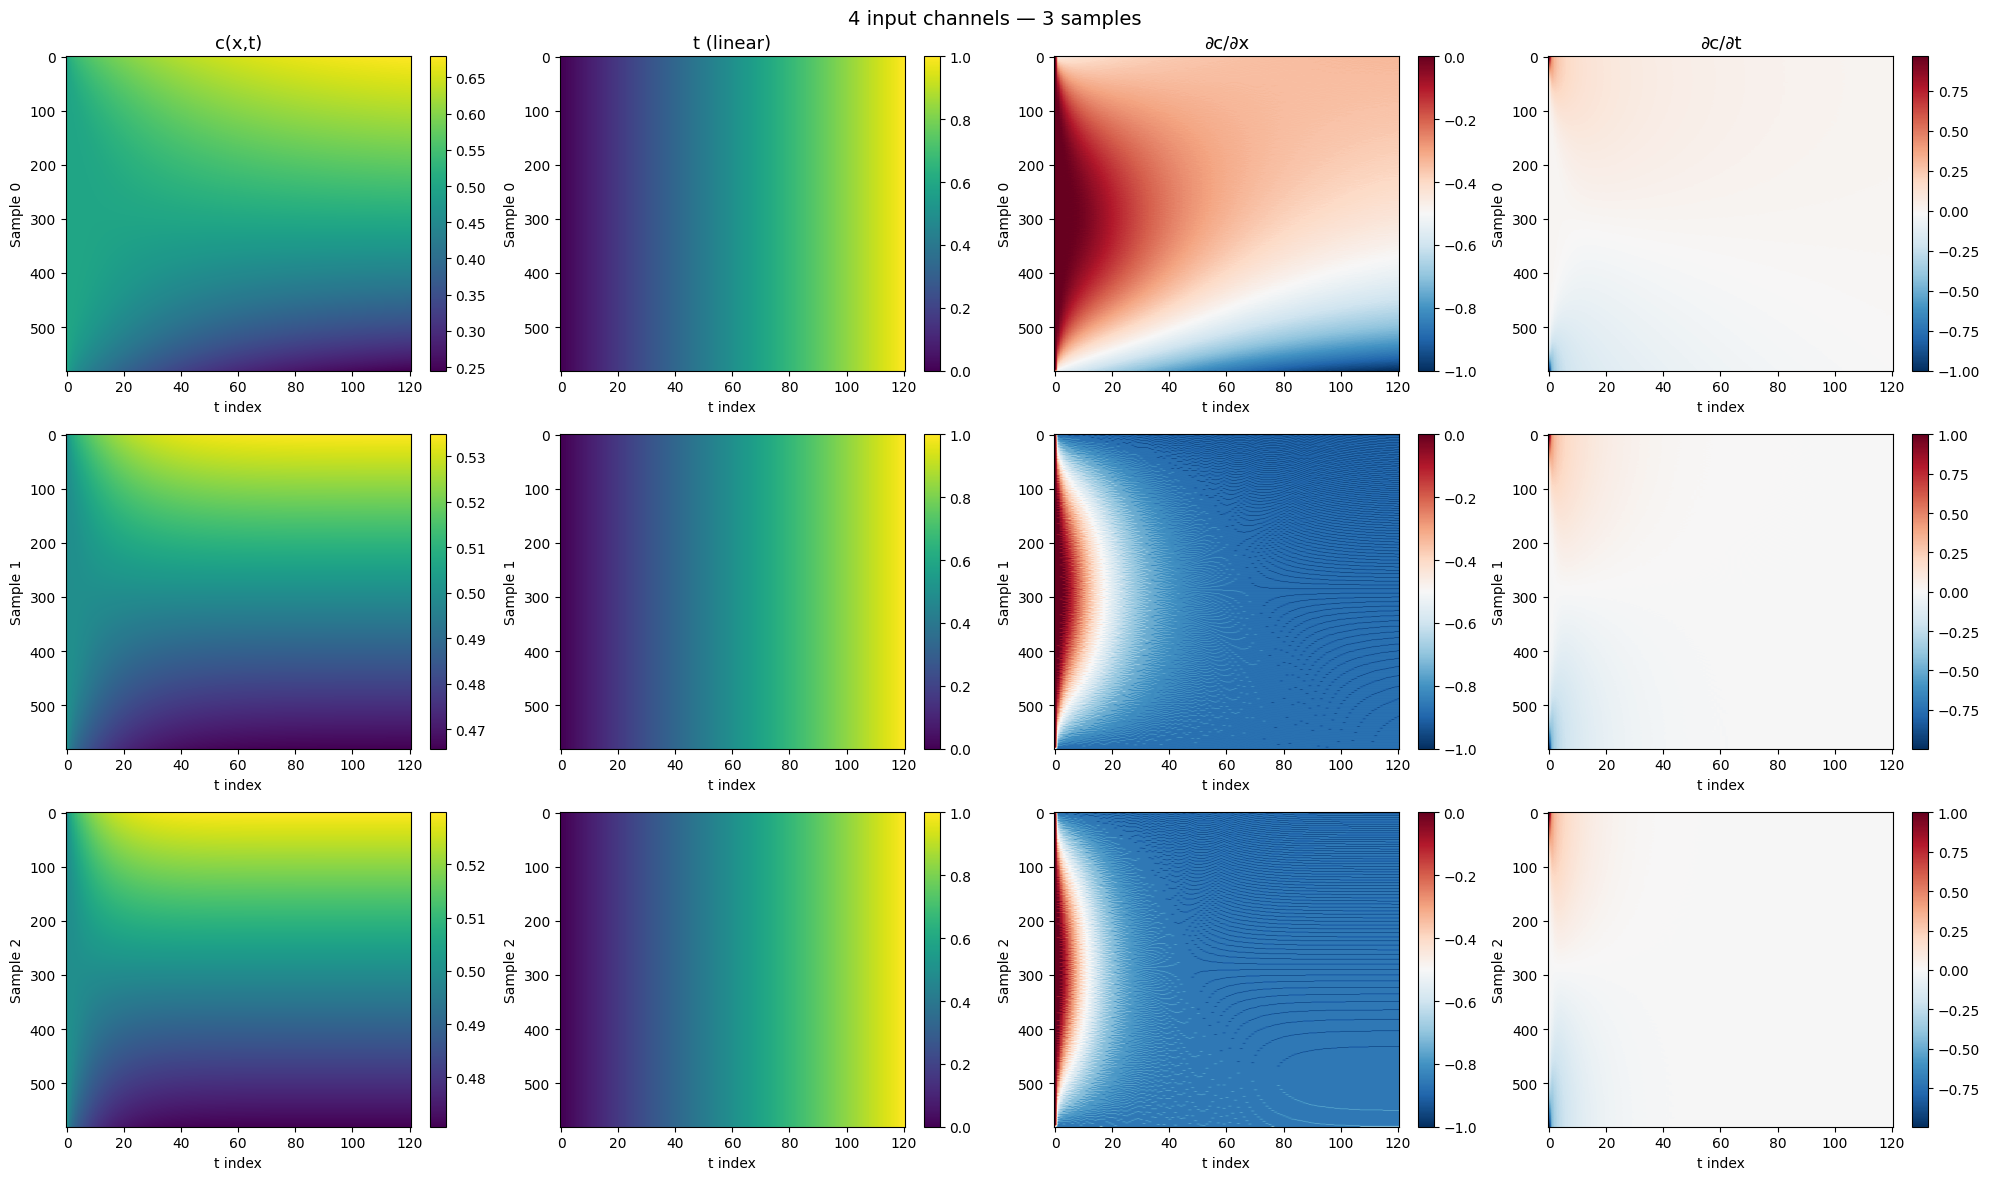


Channel statistics (first 50 samples):
  c(x,t)          min=0.2450  max=0.6791  mean=0.5000  std=0.0391
  t (linear)      min=0.0000  max=1.0000  mean=0.5000  std=0.2911
  ∂c/∂x           min=-1.0000  max=0.0000  mean=-0.7141  std=0.2322
  ∂c/∂t           min=-1.0000  max=1.0000  mean=-0.0000  std=0.0561


In [9]:
# ============================================================================
# VISUALIZE
# ============================================================================

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
titles = ['c(x,t)', 't (linear)', '∂c/∂x', '∂c/∂t']
cmaps = ['viridis', 'viridis', 'RdBu_r', 'RdBu_r']

for row, sample_idx in enumerate([0, 1, 2]):
    inp, tgt = dataset[sample_idx]
    for ch in range(4):
        im = axes[row, ch].imshow(inp[ch].numpy(), aspect='auto', cmap=cmaps[ch])
        if row == 0:
            axes[row, ch].set_title(titles[ch], fontsize=13)
        axes[row, ch].set_ylabel(f'Sample {sample_idx}')
        axes[row, ch].set_xlabel('t index')
        plt.colorbar(im, ax=axes[row, ch], fraction=0.046)

plt.suptitle('4 input channels — 3 samples', fontsize=14)
plt.tight_layout()
plt.show()

print("\nChannel statistics (first 50 samples):")
for ch, name in enumerate(titles):
    vals = np.stack([dataset[i][0][ch].numpy() for i in range(min(50, len(dataset)))])
    print(f"  {name:<15s} min={vals.min():.4f}  max={vals.max():.4f}  "
          f"mean={vals.mean():.4f}  std={vals.std():.4f}")


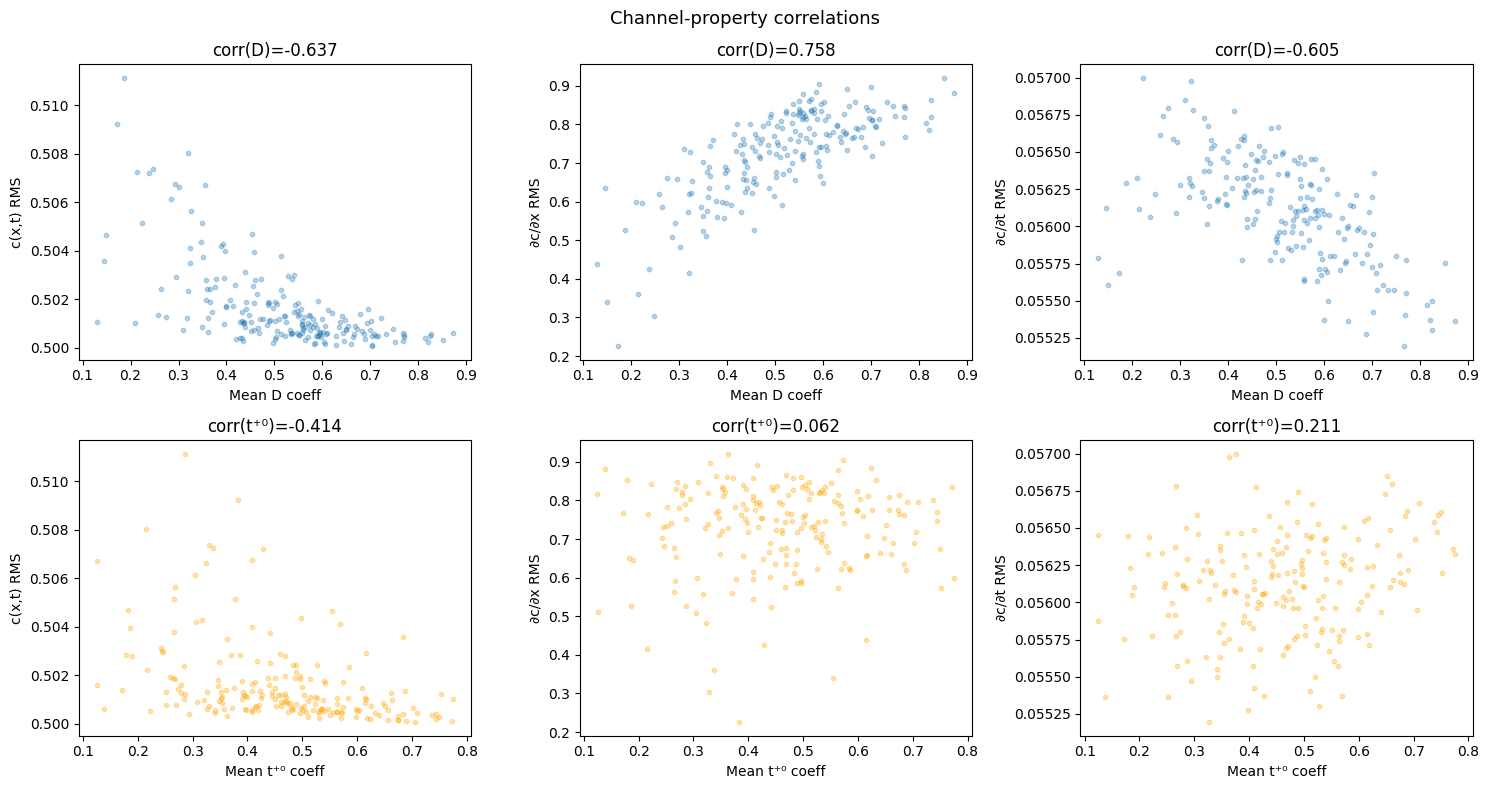

In [10]:
# ============================================================================
# DIAGNOSTIC: channel-property correlations
# ============================================================================

n_check = min(200, len(dataset))
D_mean = dataset.targets['D'][:n_check].mean(axis=1)
tp_mean = dataset.targets['t_param'][:n_check].mean(axis=1)

ch_names = ['c(x,t)', 't (linear)', '∂c/∂x', '∂c/∂t']
ch_data = [dataset.c_grids, None, dataset.dcdx, dataset.dcdt]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))  # skip time channel (constant)

plot_idx = 0
for ch in [0, 2, 3]:  # skip ch 1 (time is same for all)
    ch_rms = np.sqrt((ch_data[ch][:n_check] ** 2).mean(axis=(1, 2)))
    
    corr_D = np.corrcoef(D_mean, ch_rms)[0, 1]
    axes[0, plot_idx].scatter(D_mean, ch_rms, alpha=0.3, s=10)
    axes[0, plot_idx].set_xlabel('Mean D coeff')
    axes[0, plot_idx].set_ylabel(f'{ch_names[ch]} RMS')
    axes[0, plot_idx].set_title(f'corr(D)={corr_D:.3f}')
    
    corr_tp = np.corrcoef(tp_mean, ch_rms)[0, 1]
    axes[1, plot_idx].scatter(tp_mean, ch_rms, alpha=0.3, s=10, c='orange')
    axes[1, plot_idx].set_xlabel('Mean t⁺⁰ coeff')
    axes[1, plot_idx].set_ylabel(f'{ch_names[ch]} RMS')
    axes[1, plot_idx].set_title(f'corr(t⁺⁰)={corr_tp:.3f}')
    
    plot_idx += 1

plt.suptitle('Channel-property correlations', fontsize=13)
plt.tight_layout()
plt.show()


In [11]:
# ============================================================================
# VERIFY: compatible with training notebook
# ============================================================================

loaded = torch.load(SAVE_PATH, map_location='cpu', weights_only=False)

inp, tgt = loaded[0]
print(f"Input shape:  {tuple(inp.shape)}  (expect (4, {loaded.N_x}, {loaded.N_t}))")
print(f"D shape:      {tuple(tgt['D'].shape)}")
print(f"t_param shape: {tuple(tgt['t_param'].shape)}")
assert inp.shape[0] == 4, "Expected 4 channels!"
print("\n✓ Ready for training notebook")
print(f"\nIn training notebook, set:")
print(f"  DATA_PATH = '{SAVE_PATH}'")
print(f"  N_CHANNELS = 4")


Input shape:  (4, 581, 121)  (expect (4, 581, 121))
D shape:      (4,)
t_param shape: (4,)

✓ Ready for training notebook

In training notebook, set:
  DATA_PATH = 'fixed_rho_data_4ch.pt'
  N_CHANNELS = 4


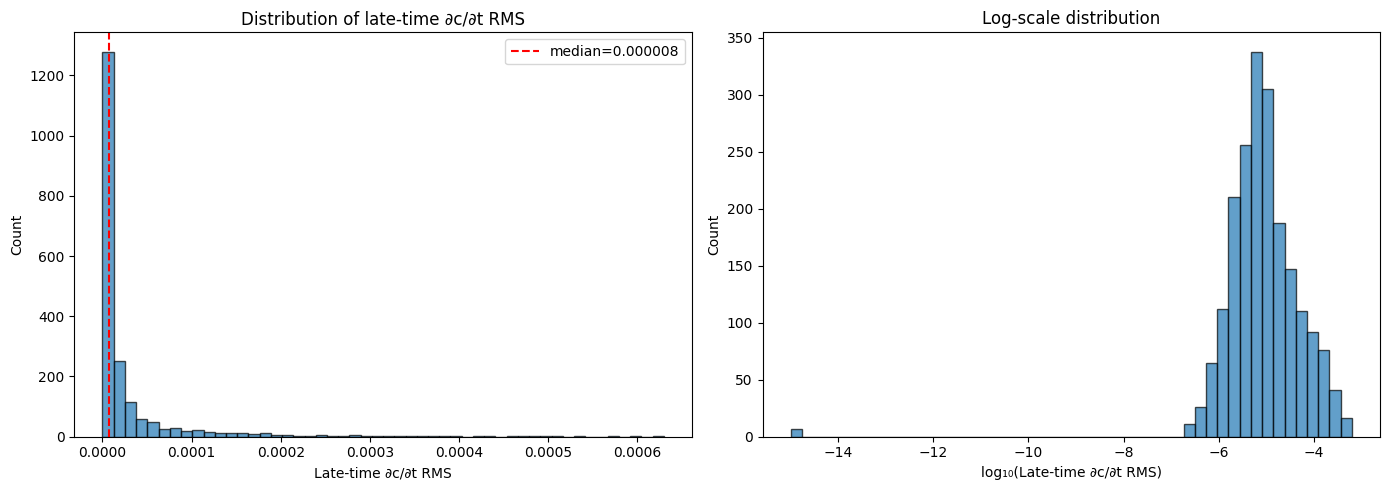

Late-time ∂c/∂t RMS statistics:
  min:    0.00000000
  median: 0.00000781
  mean:   0.00003058
  max:    0.00062994

With threshold = 0.00000781:
  Steady-state samples: 1000 (50.0%)
  Transient samples:    1000 (50.0%)


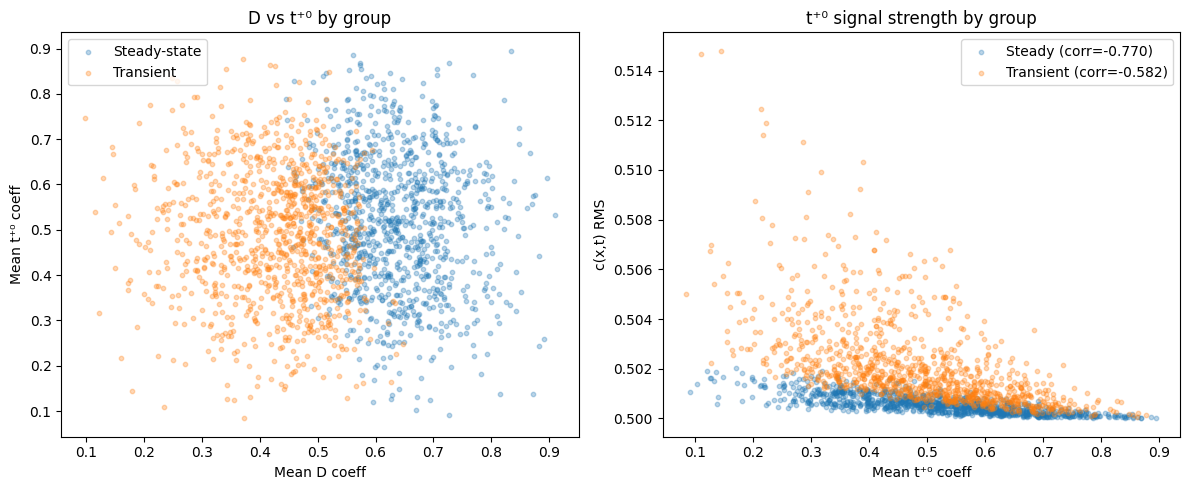


t⁺⁰ correlation with c(x,t) RMS:
  Steady-state: -0.7696
  Transient:    -0.5820
→ Steady-state samples have stronger t⁺⁰ signal (as expected from physics)
→ Consider training a separate t⁺⁰ model on steady-state samples only

Mask saved to steady_state_mask.npy
Use in training: is_steady = np.load('steady_state_mask.npy')


In [12]:


# ============================================================================
# Classify samples: steady-state vs still-evolving
# ============================================================================
# 
# Logic: if ∂c/∂t is small at the end of the simulation, the sample
# has reached steady state. If it's still large, it hasn't.
#
# Add this after loading the dataset in your training notebook.
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt

# Assume `dataset` is already loaded
# dataset.dcdt has shape (N_samples, N_x, N_t)
# dataset.c_grids has shape (N_samples, N_x, N_t)

# ── 1. Measure how "steady" each sample is ──────────────────────────
# Use RMS of ∂c/∂t over the last 10% of time steps
N_t = dataset.dcdt.shape[2]
late_fraction = 0.1
late_start = int(N_t * (1 - late_fraction))

# RMS of ∂c/∂t at late times (unnormalized dcdt needed — 
# but since we normalized per-sample, use the raw c_grids instead)
late_dcdt_rms = np.zeros(len(dataset))
for i in range(len(dataset)):
    c = dataset.c_grids[i]                          # (N_x, N_t)
    # Compute raw ∂c/∂t at the last few time steps
    late_c = c[:, late_start:]                       # (N_x, ~10% of N_t)
    if late_c.shape[1] > 1:
        dcdt_late = np.diff(late_c, axis=1)
        late_dcdt_rms[i] = np.sqrt((dcdt_late ** 2).mean())
    else:
        late_dcdt_rms[i] = 0.0

# ── 2. Find a threshold ─────────────────────────────────────────────
# Plot distribution to pick a sensible cutoff
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(late_dcdt_rms, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Late-time ∂c/∂t RMS')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of late-time ∂c/∂t RMS')
axes[0].axvline(x=np.median(late_dcdt_rms), color='r', linestyle='--', 
                label=f'median={np.median(late_dcdt_rms):.6f}')
axes[0].legend()

# Log scale version (if distribution is skewed)
axes[1].hist(np.log10(late_dcdt_rms + 1e-15), bins=50, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('log₁₀(Late-time ∂c/∂t RMS)')
axes[1].set_ylabel('Count')
axes[1].set_title('Log-scale distribution')
plt.tight_layout()
plt.show()

print(f"Late-time ∂c/∂t RMS statistics:")
print(f"  min:    {late_dcdt_rms.min():.8f}")
print(f"  median: {np.median(late_dcdt_rms):.8f}")
print(f"  mean:   {late_dcdt_rms.mean():.8f}")
print(f"  max:    {late_dcdt_rms.max():.8f}")

# ── 3. Classify ─────────────────────────────────────────────────────
# Use median as initial threshold — adjust after seeing the histogram
threshold = np.median(late_dcdt_rms)

is_steady = late_dcdt_rms < threshold
is_transient = ~is_steady

n_steady = is_steady.sum()
n_transient = is_transient.sum()

print(f"\nWith threshold = {threshold:.8f}:")
print(f"  Steady-state samples: {n_steady} ({100*n_steady/len(dataset):.1f}%)")
print(f"  Transient samples:    {n_transient} ({100*n_transient/len(dataset):.1f}%)")

# ── 4. Check: do the two groups have different t⁺⁰ sensitivity? ────
D_mean = dataset.targets['D'].mean(axis=1)
tp_mean = dataset.targets['t_param'].mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(D_mean[is_steady], tp_mean[is_steady], alpha=0.3, s=10, label='Steady-state')
axes[0].scatter(D_mean[is_transient], tp_mean[is_transient], alpha=0.3, s=10, label='Transient')
axes[0].set_xlabel('Mean D coeff')
axes[0].set_ylabel('Mean t⁺⁰ coeff')
axes[0].set_title('D vs t⁺⁰ by group')
axes[0].legend()

# Key question: does c(x,t) correlate better with t⁺⁰ in steady-state samples?
c_rms_all = np.sqrt((dataset.c_grids ** 2).mean(axis=(1, 2)))

corr_tp_steady = np.corrcoef(tp_mean[is_steady], c_rms_all[is_steady])[0, 1]
corr_tp_transient = np.corrcoef(tp_mean[is_transient], c_rms_all[is_transient])[0, 1]

axes[1].scatter(tp_mean[is_steady], c_rms_all[is_steady], 
                alpha=0.3, s=10, label=f'Steady (corr={corr_tp_steady:.3f})')
axes[1].scatter(tp_mean[is_transient], c_rms_all[is_transient], 
                alpha=0.3, s=10, label=f'Transient (corr={corr_tp_transient:.3f})')
axes[1].set_xlabel('Mean t⁺⁰ coeff')
axes[1].set_ylabel('c(x,t) RMS')
axes[1].set_title('t⁺⁰ signal strength by group')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nt⁺⁰ correlation with c(x,t) RMS:")
print(f"  Steady-state: {corr_tp_steady:.4f}")
print(f"  Transient:    {corr_tp_transient:.4f}")

if abs(corr_tp_steady) > abs(corr_tp_transient) + 0.1:
    print("→ Steady-state samples have stronger t⁺⁰ signal (as expected from physics)")
    print("→ Consider training a separate t⁺⁰ model on steady-state samples only")

# ── 5. Save the mask for use in training ────────────────────────────
np.save('steady_state_mask.npy', is_steady)
print(f"\nMask saved to steady_state_mask.npy")
print(f"Use in training: is_steady = np.load('steady_state_mask.npy')")